In [25]:
import smote_variants as sv

import numpy as np
import pandas as pd



from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.kernel_approximation import RBFSampler

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score,f1_score, accuracy_score,mean_squared_error,mean_absolute_error)
from sklearn.preprocessing import Normalizer
from pandas_ml import ConfusionMatrix

In [26]:
train = pd.read_csv('UNSW_NB15_training-set.csv')
test = pd.read_csv('UNSW_NB15_testing-set.csv')
combined_data = pd.concat([train, test]).drop(['id'],axis=1)

In [27]:
combined_data.head(3)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,...,1,2,0,0,0,1,2,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,...,1,2,0,0,0,1,2,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,...,1,3,0,0,0,1,3,0,Normal,0


In [28]:
# Contaminsation mean pollution (outliers) in data
tmp = train.where(train['attack_cat'] == "Normal").dropna()
contamination = round(1 - len(tmp)/len(train), 2)
print("train contamination ", contamination)

tmp = test.where(test['attack_cat'] == "Normal").dropna()
print("test  contamination ", round(1 - len(tmp)/len(test),2),'\n')

if contamination > 0.5:
    print(f'contamination is {contamination}, which is greater than 0.5. Fixing...')
    contamination = round(1-contamination,2)
    print(f'contamination is now {contamination}')

train contamination  0.55
test  contamination  0.68 

contamination is 0.55, which is greater than 0.5. Fixing...
contamination is now 0.45


In [29]:
from sklearn.preprocessing import LabelEncoder,normalize
le1 = LabelEncoder()
le = LabelEncoder()

vector = combined_data['attack_cat']

print("attack cat:", set(list(vector))) # use print to make it print on single line 

combined_data['attack_cat'] = le1.fit_transform(vector)
combined_data['proto'] = le.fit_transform(combined_data['proto'])
combined_data['service'] = le.fit_transform(combined_data['service'])
combined_data['state'] = le.fit_transform(combined_data['state'])

vector = combined_data['attack_cat']
print('\nDescribing attack_type: ')
print("min", vector.min())
print("max", vector.max())
print("mode",vector.mode(), "Which is,", le1.inverse_transform(vector.mode()))
print("mode", len(np.where(vector.values==6)[0])/len(vector),"%")

attack cat: {'Backdoor', 'Exploits', 'Worms', 'DoS', 'Reconnaissance', 'Normal', 'Fuzzers', 'Analysis', 'Generic', 'Shellcode'}

Describing attack_type: 
min 0
max 9
mode 0    6
dtype: int32 Which is, ['Normal']
mode 0.3609225646458884 %


In [30]:
combined_data[combined_data['attack_cat'] == 5].shape[0]

58871

In [31]:
## OMITTED: For statistical feature removal

lowSTD = list(combined_data.std().to_frame().nsmallest(6, columns=0).index)
# this is stupid. suppose a feature has a 1.0 (spearman or pearson) correlation, OR conditional probability, when not 0.... That a very useful feature  

lowCORR = list(combined_data.corr().abs().sort_values('attack_cat')['attack_cat'].nsmallest(3).index) # .where(lambda x: x < 0.005).dropna()
# This might be stupid. A Deep MLP (feed forward neural net) may see patterns

drop = set( lowCORR + lowSTD)
drop = {'ackdat', 'ct_ftp_cmd', 'djit', 'is_ftp_login', 'is_sm_ips_ports', 'response_body_len', 'sjit', 'synack', 'tcprtt'}
# print(f'Before {combined_data.shape}')
combined_data_reduced=combined_data.drop(drop,axis=1)
# print(f'After {combined_data.shape}')

In [32]:
data_x = combined_data_reduced.drop(['attack_cat','label'], axis=1) # droped label
data_y = combined_data_reduced.loc[:,['label']]
# # del combined_data # free mem
X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=.20, random_state=42) # TODO

In [33]:
d0 = combined_data_reduced.query('attack_cat == [0] ')
d1 = combined_data_reduced.query('attack_cat == [1] ')
d2 = combined_data_reduced.query('attack_cat == [2] ')
d3 = combined_data_reduced.query('attack_cat == [3] ')
d4 = combined_data_reduced.query('attack_cat == [4] ')
d5 = combined_data_reduced.query('attack_cat == [5] ')
d6 = combined_data_reduced.query('attack_cat == [6] ')
d7 = combined_data_reduced.query('attack_cat == [7] ')
d8 = combined_data_reduced.query('attack_cat == [8] ')
d9 = combined_data_reduced.query('attack_cat == [9] ')

dt={'0':pd.Series(d0.shape[0],index=['total']),
    '1':pd.Series(d1.shape[0],index=['total']),
    '2':pd.Series(d2.shape[0],index=['total']),
    '3':pd.Series(d3.shape[0],index=['total']),
    '4':pd.Series(d4.shape[0],index=['total']),
    '5':pd.Series(d5.shape[0],index=['total']),
    '6':pd.Series(d6.shape[0],index=['total']),
    '7':pd.Series(d7.shape[0],index=['total']),
    '8':pd.Series(d8.shape[0],index=['total']),
    '9':pd.Series(d9.shape[0],index=['total']),
    
   }
type_df=pd.DataFrame(dt)
# cols = ['Normal','Worms', 'DoS', 'Shellcode', 'Exploits', 'Analysis', 'Backdoor', 'Reconnaissance', 'Fuzzers', 'Normal', 'Generic']
# type_df = type_df[cols]
display(type_df)

,0,1,2,3,4,5,6,7,8,9
total,2677,2329,16353,44525,24246,58871,93000,13987,1511,174


attack_cat = '6' 表示正常类型
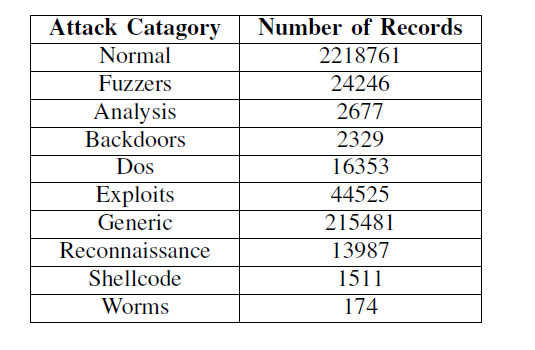

In [34]:
# combined_data_reduced.max(),combined_data_reduced.min(),

In [35]:
# combined_data_reduced.query('attack_cat == [0,1,8,9] ')

In [36]:




# combined_data_reduced2.replace([np.inf, -np.inf], 1, inplace=True)
selectedSmoteData = combined_data_reduced.query('attack_cat == [0,1,8,9] ')
remainData = combined_data_reduced.query('attack_cat == [2,3,4,5,6,7] ')

select_X = selectedSmoteData.drop(['attack_cat','label'], axis=1)
select_y = selectedSmoteData.loc[:,['attack_cat']]
# print(smote_data_y.isnull().any())
# smote_data_x.replace([np.inf, -np.inf], np.nan, inplace=True)
# smote_data_x.fillna(0, inplace=True)

In [37]:
scaler = Normalizer().fit(select_X)
scaler_X = scaler.transform(select_X)
pd_selsct_X = pd.DataFrame(scaler_X)

# pd_selsct_X[np.isfinite(pd_selsct_X)] = 1
# pd_selsct_X = pd_selsct_X.fillna(1)
pd_selsct_X.shape

(6691, 33)

In [38]:
# pd_selsct_X2 = pd_selsct_X.round(5)

# np.any(np.isnan(pd_selsct_X))
# np.any(np.isfinite(pd_selsct_X))
# pd_selsct_X3 = pd_selsct_X.replace([np.inf, -np.inf], np.nan, inplace=True)
# pd_selsct_X3 = pd_selsct_X.dropna(axis = 1, how = 'any')

np_select_X = select_X.values
np_select_y = select_y.values.flatten()

In [39]:
import sys
sys.setrecursionlimit(100000000)


oversampler= sv.MulticlassOversampling(sv.distance_SMOTE())
X_samp, y_samp= oversampler.sample(np_select_X, np_select_y)



2021-08-29 10:38:44,263:INFO:MulticlassOversampling: Running multiclass oversampling with strategy eq_1_vs_many_successive
2021-08-29 10:38:44,266:INFO:MulticlassOversampling: Sampling minority class with label: 1
2021-08-29 10:38:44,269:INFO:distance_SMOTE: Running sampling via ('distance_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'n_jobs': 1, 'random_state': None}")
2021-08-29 10:38:44,351:INFO:MulticlassOversampling: Sampling minority class with label: 8
2021-08-29 10:38:44,354:INFO:distance_SMOTE: Running sampling via ('distance_SMOTE', "{'proportion': 0.30340879521207392, 'n_neighbors': 5, 'n_jobs': 1, 'random_state': None}")
2021-08-29 10:38:44,408:INFO:MulticlassOversampling: Sampling minority class with label: 9
2021-08-29 10:38:44,410:INFO:distance_SMOTE: Running sampling via ('distance_SMOTE', "{'proportion': 0.31856942853506426, 'n_neighbors': 5, 'n_jobs': 1, 'random_state': None}")


In [40]:
for i in np.unique(y_samp):
    print("class %d - samples: %d" % (i, np.sum(y_samp == i)))

class 0 - samples: 2677
class 1 - samples: 2677
class 8 - samples: 2677
class 9 - samples: 2677


In [41]:

y_samp2 = y_samp
y_samp2 = np.where(y_samp2 == 6 ,0,1)

In [42]:
for i in np.unique(y_samp2):
    print("class %d - samples: %d" % (i, np.sum(y_samp2 == i)))

class 1 - samples: 10708


In [43]:
remainData = combined_data_reduced.query('attack_cat == [2,3,4,5,6,7] ')
origin_X = combined_data_reduced.drop(['attack_cat','label'], axis=1)
origin_y = combined_data_reduced.loc[:,['attack_cat']]

remain_X = remainData.drop(['attack_cat','label'], axis=1)
remain_y = remainData.loc[:,['attack_cat']]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(origin_X, origin_y, test_size=.20, random_state=42)

In [45]:
X_real_train = np.append(remain_X.values, X_samp, axis = 0)
y_real_train = np.where(np.append(remain_y.values, y_samp) == 6 ,0,1)
X_real_test = X_test.values
y_real_test = np.where(y_test.values == 6,0,1).flatten()

In [46]:
print(X_real_train.shape)
print(y_real_train.shape)
print(X_real_test.shape) # test is larger... good 
print(y_real_test.shape)
# y_train.min()

(261690, 33)
(261690,)
(51535, 33)
(51535,)


In [47]:
# traindata = pd.read_csv('UNSW_NB15_training-set.csv', header=None)
# testdata = pd.read_csv('UNSW_NB15_testing-set.csv', header=None)
# traindata = pd.read_csv('kddtrain.csv', header=None)
# testdata = pd.read_csv('kddtest.csv', header=None)

# X = traindata.iloc[:,1:42]
# Y = traindata.iloc[:,0]
# C = testdata.iloc[:,0]
# T = testdata.iloc[:,1:42]
X = X_real_train
Y = y_real_train
T = X_real_test
C = y_real_test

scaler = Normalizer().fit(X)
trainX = scaler.transform(X)
scaler = Normalizer().fit(T)
testT = scaler.transform(T)


traindata = np.array(trainX)
trainlabel = np.array(Y)
testdata = np.array(testT)
testlabel = np.array(C)





D:\Anaconda3\envs\TF_36a\lib\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


(51535,)
(51535,)
***************************************************************


In [51]:
model = LogisticRegression()
model.fit(traindata, trainlabel)
print(model)

# make predictions
expected = testlabel
predicted = model.predict(testdata)

#predicted = predicted.reshape(len(predicted),1)
print(expected.shape)
print(predicted.shape)


cm = ConfusionMatrix(expected, predicted)

expected = np.array(expected)
predicted = np.array(predicted)
cm.print_stats()

np.savetxt('expected.txt', expected, fmt='%01d')
np.savetxt('predicted.txt',predicted , fmt='%01d')

print(cm)
print(expected.shape)
print(predicted.shape)
cm.stats()
print("***************************************************************")



D:\Anaconda3\envs\TF_36a\lib\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)
(51535,)
(51535,)
population: 51535
P: 32860
N: 18675
PositiveTest: 29512
NegativeTest: 22023
TP: 24778
TN: 13941
FP: 4734
FN: 8082
TPR: 0.754047474133
TNR: 0.746506024096
PPV: 0.83959067498
NPV: 0.63302002452
FPR: 0.253493975904
FDR: 0.16040932502
FNR: 0.245952525867
ACC: 0.751314640536
F1_score: 0.79452318348
MCC: 0.486381474704
informedness: 0.500553498229
markedness: 0.472610699499
prevalence: 0.637624915106
LRP: 2.97461693693
LRN: 0.32947158888
DOR: 9.02844748175
FOR: 0.36697997548
Predicted  False   True  __all__
Actual                          
False      13941   4734    18675
True        8082  24778    32860
__all__    22023  29512    51535
(51535,)
(51535,)
*************************************************************

In [48]:



# fit a Naive Bayes model to the data
model = GaussianNB()
model.fit(traindata, trainlabel)
print(model)
# make predictions
expected = testlabel
predicted = model.predict(testdata)

expected = expected.flatten()
#predicted = predicted.reshape(len(predicted),1)
print(expected.shape)
print(predicted.shape)

cm = ConfusionMatrix(expected, predicted)

expected = np.array(expected)
predicted = np.array(predicted)
cm.print_stats()

np.savetxt('expected.txt', expected, fmt='%01d')
np.savetxt('predicted.txt',predicted , fmt='%01d')

print(cm)
print(expected.shape)
print(predicted.shape)
cm.stats()
print("***************************************************************")



# fit a k-nearest neighbor model to the data
model = KNeighborsClassifier()
model.fit(traindata, trainlabel)
print(model)
# make predictions
expected = testlabel
predicted = model.predict(testdata)
# summarize the fit of the model

expected = expected.flatten()
print(expected.shape)
print(predicted.shape)

cm = ConfusionMatrix(expected, predicted)
expected = np.array(expected)
predicted = np.array(predicted)
cm.print_stats()
np.savetxt('expected.txt', expected, fmt='%01d')
np.savetxt('predicted.txt',predicted , fmt='%01d')
print(cm)
print(expected.shape)
print(predicted.shape)
cm.stats()

print("***************************************************************")
model = DecisionTreeClassifier()
model.fit(traindata, trainlabel)
print(model)
# make predictions
expected = testlabel
predicted = model.predict(testdata)
# summarize the fit of the model

expected = expected.flatten()

cm = ConfusionMatrix(expected, predicted)
expected = np.array(expected)
predicted = np.array(predicted)
cm.print_stats()
np.savetxt('expected.txt', expected, fmt='%01d')
np.savetxt('predicted.txt',predicted , fmt='%01d')
print(cm)
print(expected.shape)
print(predicted.shape)
cm.stats()


print("***************************************************************")


print("AdaBoostClassifier(n_estimators=100)")

model = AdaBoostClassifier(n_estimators=100)
model.fit(traindata, trainlabel)

# make predictions
expected = testlabel
predicted = model.predict(testdata)
# summarize the fit of the model

expected = expected.flatten()

cm = ConfusionMatrix(expected, predicted)
expected = np.array(expected)
predicted = np.array(predicted)
cm.print_stats()
np.savetxt('expected.txt', expected, fmt='%01d')
np.savetxt('predicted.txt',predicted , fmt='%01d')
print(cm)
print(expected.shape)
print(predicted.shape)
cm.stats()

print("***************************************************************")



print("RandomForestClassifier(n_estimators=100)")
model = RandomForestClassifier(n_estimators=100)
model = model.fit(traindata, trainlabel)

# make predictions
expected = testlabel
predicted = model.predict(testdata)
# summarize the fit of the model
expected = expected.flatten()

cm = ConfusionMatrix(expected, predicted)
expected = np.array(expected)
predicted = np.array(predicted)
cm.print_stats()
np.savetxt('expected.txt', expected, fmt='%01d')
np.savetxt('predicted.txt',predicted , fmt='%01d')
print(cm)
print(expected.shape)
print(predicted.shape)
cm.stats()

print("***************************************************************")

print("svm.SVC(kernel='linear')")
model = svm.SVC(kernel='linear')#调参
model = model.fit(traindata, trainlabel)

# make predictions
expected = testlabel
predicted = model.predict(testdata)
# summarize the fit of the model
expected = expected.flatten()

cm = ConfusionMatrix(expected, predicted)
expected = np.array(expected)
predicted = np.array(predicted)
cm.print_stats()
np.savetxt('expected.txt', expected, fmt='%01d')
np.savetxt('predicted.txt',predicted , fmt='%01d')
print(cm)
print(expected.shape)
print(predicted.shape)
cm.stats()

print("***************************************************************")

GaussianNB(priors=None, var_smoothing=1e-09)
(51535,)
(51535,)
population: 51535
P: 32860
N: 18675
PositiveTest: 47495
NegativeTest: 4040
TP: 32769
TN: 3949
FP: 14726
FN: 91
TPR: 0.997230675593
TNR: 0.211459170013
PPV: 0.689946310138
NPV: 0.977475247525
FPR: 0.788540829987
FDR: 0.310053689862
FNR: 0.00276932440657
ACC: 0.712486659552
F1_score: 0.815605749487
MCC: 0.373207853378
informedness: 0.208689845607
markedness: 0.667421557663
prevalence: 0.637624915106
LRP: 1.26465318937
LRN: 0.0130962606464
DOR: 96.5659758549
FOR: 0.0225247524752
Predicted  False   True  __all__
Actual                          
False       3949  14726    18675
True          91  32769    32860
__all__     4040  47495    51535
(51535,)
(51535,)
***************************************************************
KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=5, p=2,
           weights='uniform')
(51535,)
(51535,)
population: 51535
P: 328

In [49]:
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Activation, Embedding
from keras.wrappers.scikit_learn import KerasClassifier
import h5py
from keras import callbacks
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from keras.utils import to_categorical

def build_model():
    # 1. define the network
    model = Sequential()
    #model = Model()
    model.add(Dense(1024,input_dim=33,activation='relu'))  
    model.add(Dropout(0.01))
    model.add(Dense(1))
    model.add(Activation('sigmoid'))
    # try using different optimizers and different optimizer configs
    model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])   
   # model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])   
    return model

Using TensorFlow backend.


In [50]:
#DNN
batch_size = 64
checkpointer = callbacks.ModelCheckpoint(filepath="./DNNResult/checkpoint-{epoch:02d}.hdf5", verbose=1, save_best_only=True, monitor='loss')
csv_logger = CSVLogger('./DNNResult/training_set_dnnanalysis.csv',separator=',', append=False)
#model = KerasClassifier(build_fn=build_model, epochs=2, batch_size=batch_size)
model = KerasClassifier(build_fn=build_model, epochs=10, batch_size=batch_size)
model.fit(traindata, trainlabel,batch_size=batch_size, epochs=40, callbacks=[checkpointer,csv_logger])
#model.save("DNNResult/dnn1layer_model.hdf5")

# make predictions
expected = testlabel
predicted = model.predict(testdata)
# summarize the fit of the model
expected = expected.flatten()
predicted = predicted.flatten()
cm = ConfusionMatrix(expected, predicted)
expected = np.array(expected)
predicted = np.array(predicted)
cm.print_stats()
np.savetxt('expected.txt', expected, fmt='%01d')
np.savetxt('predicted.txt',predicted , fmt='%01d')
print(cm)
print(expected.shape)
print(predicted.shape)
cm.stats()

print("***************************************************************")


Epoch 1/40
261690/261690 [==============================] - 25s 94us/step - loss: 0.4421 - acc: 0.7559

Epoch 00001: loss improved from inf to 0.44215, saving model to ./DNNResult/checkpoint-01.hdf5
Epoch 2/40
261690/261690 [==============================] - 12s 45us/step - loss: 0.4156 - acc: 0.7897

Epoch 00002: loss improved from 0.44215 to 0.41560, saving model to ./DNNResult/checkpoint-02.hdf5
Epoch 3/40
261690/261690 [==============================] - 12s 46us/step - loss: 0.3971 - acc: 0.8067

Epoch 00003: loss improved from 0.41560 to 0.39713, saving model to ./DNNResult/checkpoint-03.hdf5
Epoch 4/40
261690/261690 [==============================] - 13s 49us/step - loss: 0.3872 - acc: 0.8136

Epoch 00004: loss improved from 0.39713 to 0.38718, saving model to ./DNNResult/checkpoint-04.hdf5
Epoch 5/40
261690/261690 [==============================] - 13s 51us/step - loss: 0.3817 - acc: 0.8162

Epoch 00005: loss improved from 0.38718 to 0.38167, saving model to ./DNNResult/checkpoi

Predicted  False   True  __all__
Actual                          
False      11791   6884    18675
True        2327  30533    32860
__all__    14118  37417    51535
(51535,)
(51535,)
***************************************************************
